In [1]:
import pandas as pd
from scipy.stats import fisher_exact
import numpy as np
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import os
import scipy.stats as stats

In [2]:
dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Behavior_test/SauronRaw/20241016_StandardBattery-selected/'

df_battery = pd.read_csv(dir+'StandardBattery.csv')

In [5]:
df_battery['timepoint']=(df_battery['ms']//10)
df_stimulus = df_battery.drop_duplicates(['timepoint']).set_index('timepoint')
df_stimulus = df_stimulus.loc[:,~(df_stimulus.columns=='none')]
df_stimulus.transpose()

timepoint,0,1,2,3,4,5,6,7,8,9,...,121490,121491,121492,121493,121494,121495,121496,121497,121498,121499
ms,0,10,20,30,40,50,60,70,80,90,...,1214900,1214910,1214920,1214930,1214940,1214950,1214960,1214970,1214980,1214990
white LED,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
UV LED,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
solenoid,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
fs_15_20s,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
fs_9_1.2s,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
red LED,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
soft solenoid,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
purple LED,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
blue LED,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


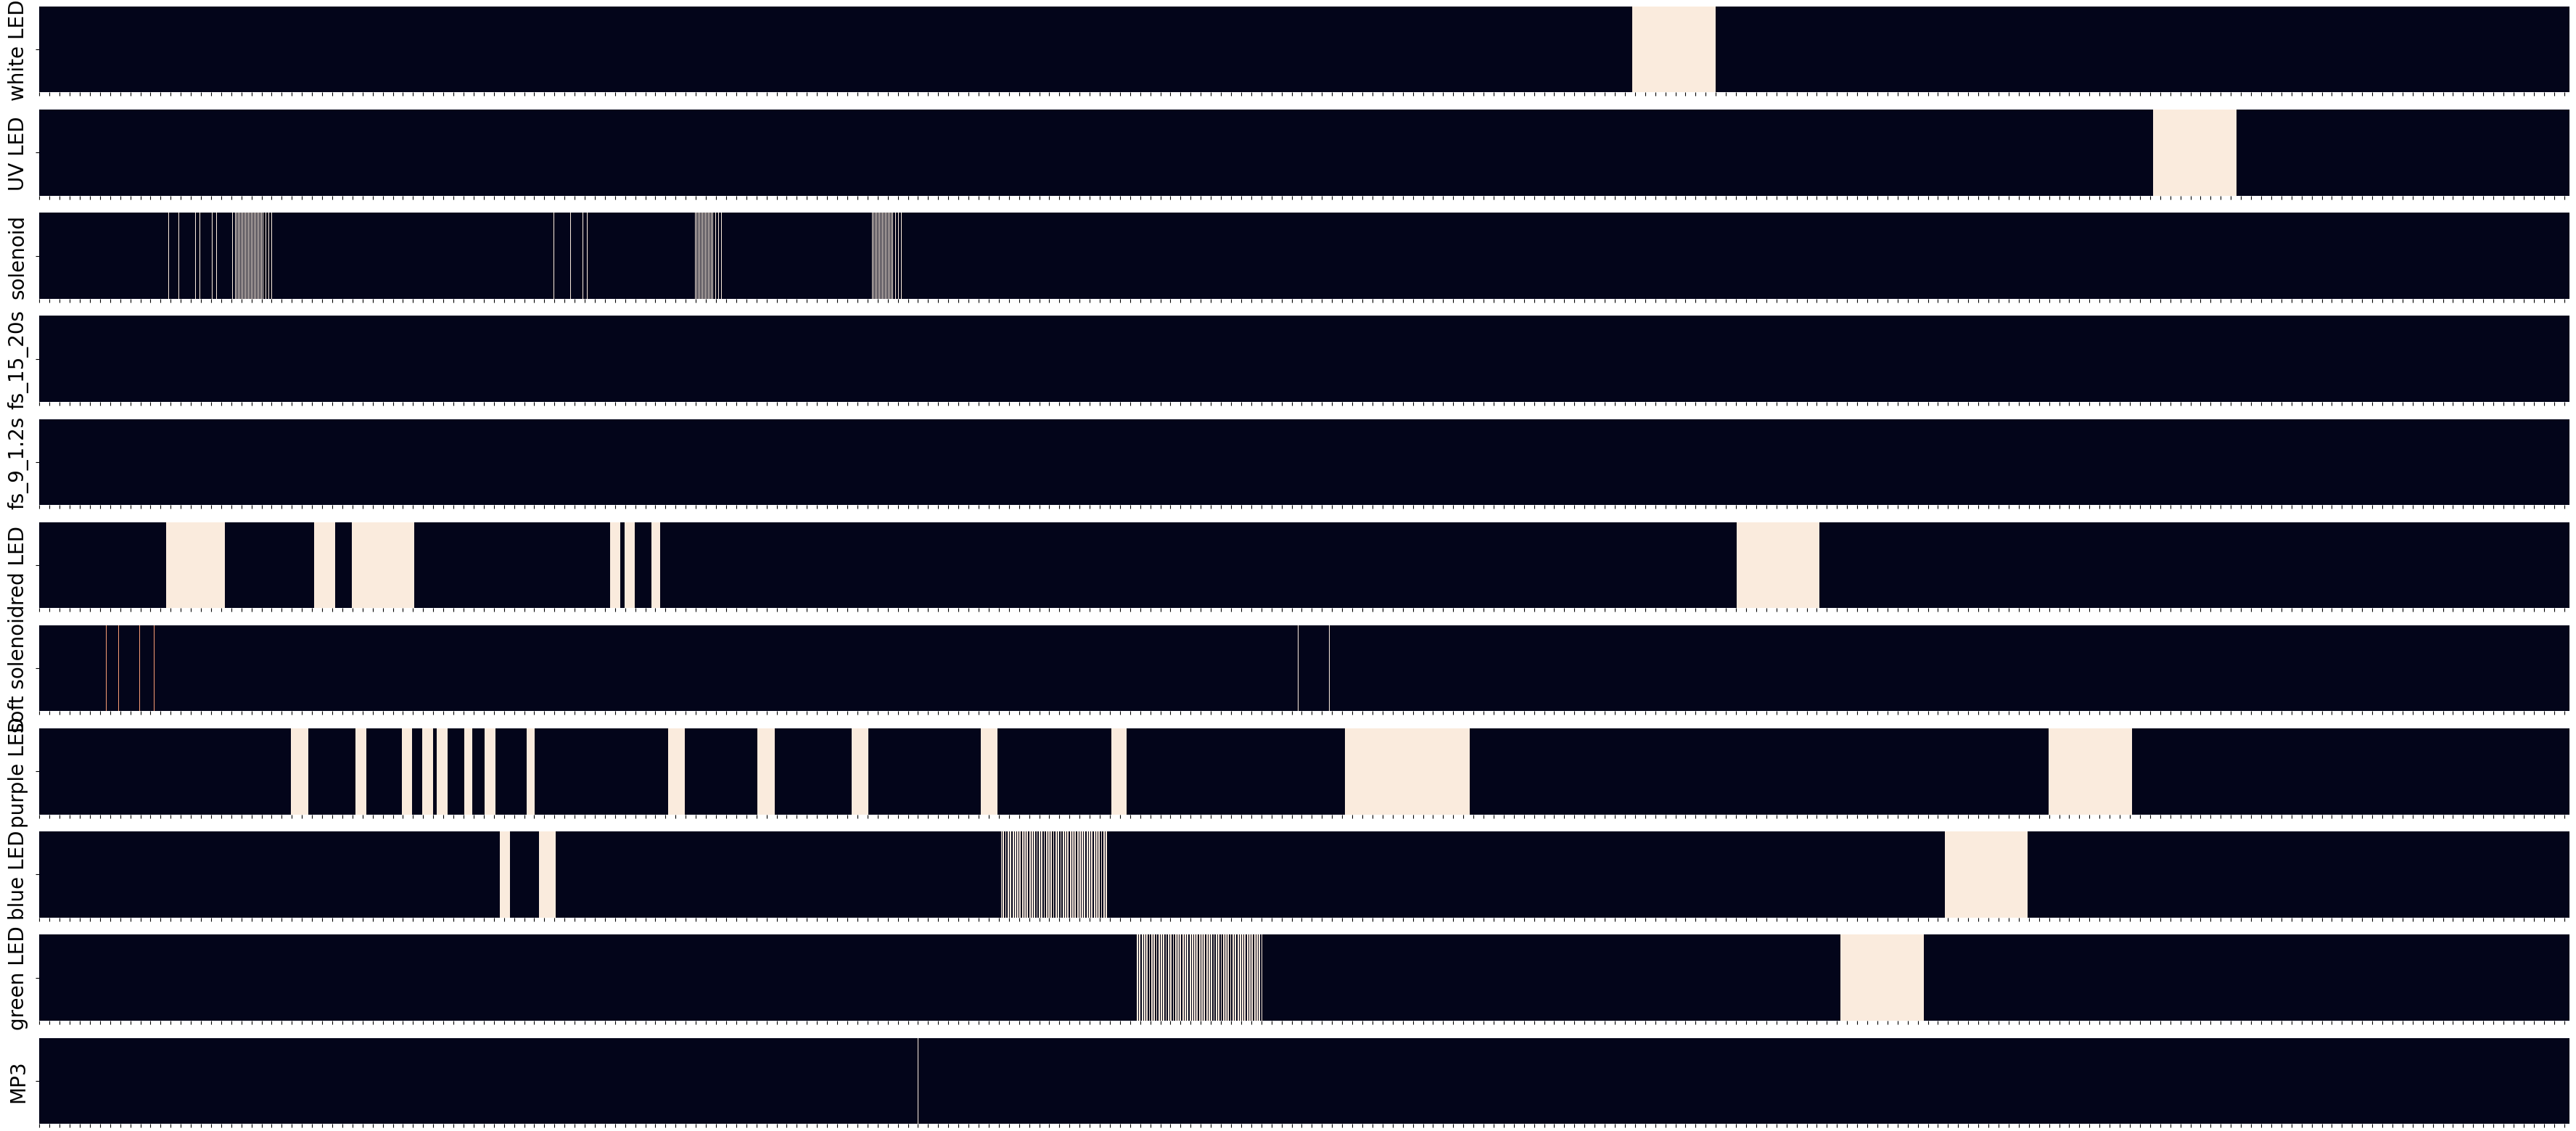

In [7]:
f, ax = plt.subplots(df_stimulus.shape[1]-1,1, figsize=(45,20), sharex=True)
distance_list = []
df_distance_dic = {}
for i in range (1, df_stimulus.shape[1]):
    sti = df_stimulus.columns[i]
    df_temp = df_stimulus.iloc[:, i:i+1].transpose()
    sti_start = df_temp.transpose()[df_temp.transpose()>0].dropna().index[0]
    sti_end = df_temp.transpose()[df_temp.transpose()>0].dropna().index[-1]
    sns.heatmap(df_temp, ax=ax[i-1], vmin=0, cbar=False)
    ax[i-1].set_xticklabels('')
    ax[i-1].set_yticklabels('')
    ax[i-1].set_ylabel(sti, fontsize=20)
    ax[i-1].set_xlabel('')
plt.show()

In [9]:
df_std_sv = pd.read_csv(dir+'10186.csv')
df_std_sv = df_std_sv.iloc[:, 41:]
df_std_sv.columns = df_std_sv.columns.astype(int)

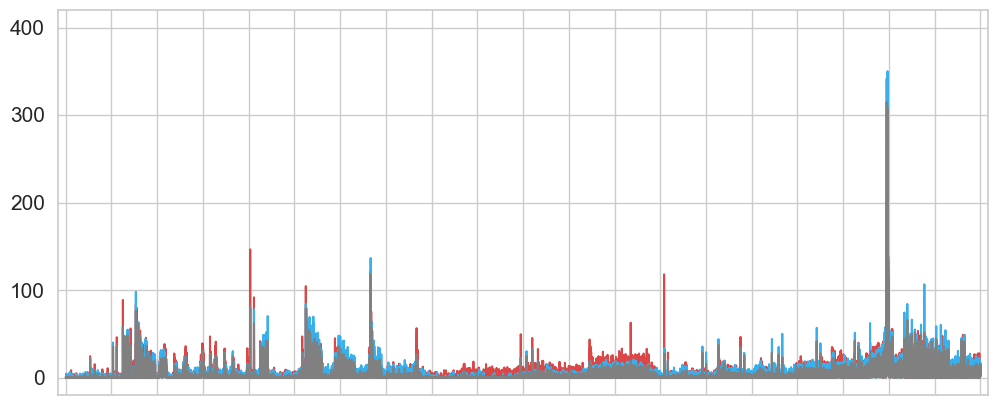

In [10]:
custom_params = {"axes.spines.right": True, "axes.spines.top": True,
                 "xtick.labelsize":15,"ytick.labelsize":15,}
sns.set_theme(style="whitegrid", rc=custom_params)

f, ax = plt.subplots(1,1, figsize=(12,5),sharey=True)
g=sns.lineplot(df_std_sv.iloc[:48, :120000].mean(), color='#db4646')
g=sns.lineplot(df_std_sv.iloc[48:, :120000].mean(), color='#37B0ED')
g=sns.lineplot(pd.concat([df_std_sv.iloc[48:, :120000].mean(),df_std_sv.iloc[:48, :120000].mean()],axis=1).min(axis=1),color='grey')
g.set_xlim(-1000,121000)
g.set_xticks(np.arange(0, 121000, 6000))
g.set_xticklabels('')

g.set_ylim(-20,420)
g.set_yticks(np.arange(0, 420, 100))
plt.show()

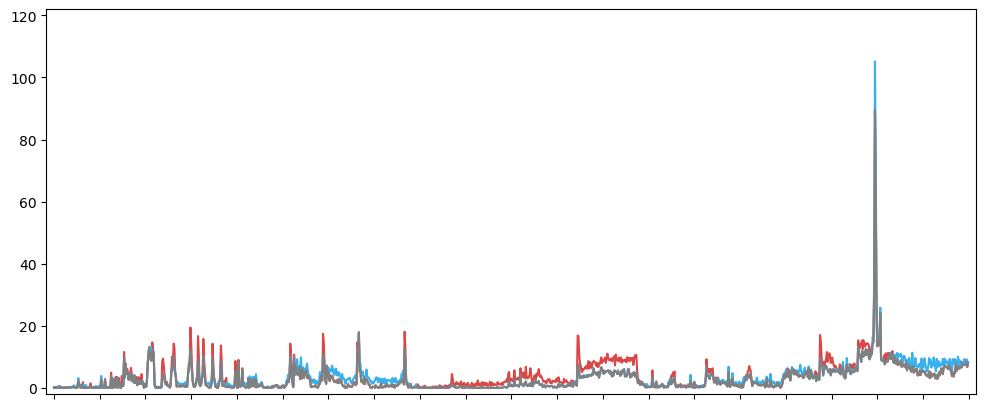

In [11]:
##plot the trace by downsampling the frames
##every 100 frames were consolidated into one frame using the mean MI
f, ax = plt.subplots(1,1, figsize=(12,5),sharey=True)
df_plot1 = df_std_sv.iloc[:48, :120000].mean().reset_index()
df_plot1['1hz'] = df_plot1['index']//100
df_plot1 = df_plot1.groupby('1hz').mean()[0]
g = sns.lineplot(df_plot1, color='#db4646')

df_plot2 = df_std_sv.iloc[48:, :120000].mean().reset_index()
df_plot2['1hz'] = df_plot2['index']//100
df_plot2 = df_plot2.groupby('1hz').mean()[0]
g = sns.lineplot(df_plot2, color='#37B0ED')

g = sns.lineplot(pd.concat([df_plot1, df_plot2],axis=1).min(axis=1), color='grey')

g.set_xlim(-10,1210)
g.set_xticks(np.arange(0, 1210, 60))
g.set_xticklabels('')
g.set_xlabel('')

g.set_ylim(-2,122)
g.set_yticks(np.arange(0, 122, 20))
g.set_ylabel('')

plt.show()

In [15]:
df_output = []
selected_tp = df_stimulus.loc[df_stimulus['soft solenoid']>0].index
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: 1 if x<=5519 else 2)
df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'soft solenoid_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'soft_solenoid_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res

,Source,ddof1,H,p-unc
1,treatment,1,0.853403,0.355591
2,treatment,1,9.248668,0.002357


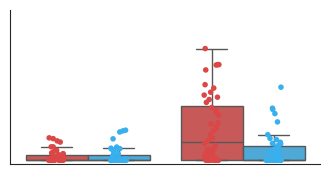

In [21]:
boxplot_accum_dpixel(df_comp)

In [31]:
selected_tp = df_stimulus.loc[df_stimulus['green LED']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: 1 if x<=12*60*100 else 2)

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'green LED_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
1,treatment,1,10.686788,0.001079,0.002158
2,treatment,1,1.168223,0.279767,0.279767


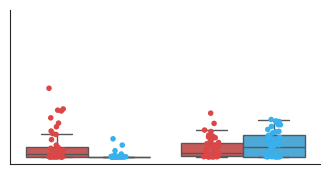

In [33]:
boxplot_accum_dpixel(df_comp)

In [35]:
selected_tp = df_stimulus.loc[df_stimulus['red LED']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = np.arange(len(starts))

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'red LED_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
0,treatment,1,0.415813,0.519034,1.000000
1,treatment,1,1.233766,0.266676,1.000000
2,treatment,1,4.134814,0.042010,0.294068
3,treatment,1,0.903077,0.341958,1.000000
4,treatment,1,0.323447,0.569543,1.000000
5,treatment,1,0.167583,0.682269,1.000000
6,treatment,1,0.667553,0.413906,1.000000


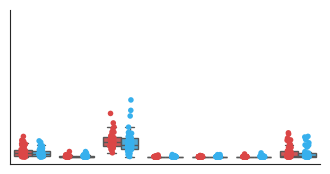

In [37]:
boxplot_accum_dpixel(df_comp)

In [39]:
selected_tp = df_stimulus.loc[df_stimulus['blue LED']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: x//10000)

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'blue LED_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
2,treatment,1,1.000457,0.317200,0.845015
4,treatment,1,1.091215,0.296202,0.845015
5,treatment,1,1.562813,0.211254,0.845015
9,treatment,1,1.417890,0.233751,0.845015


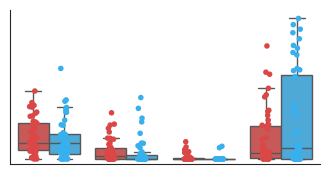

In [41]:
boxplot_accum_dpixel(df_comp)

In [43]:
selected_tp = df_stimulus.loc[df_stimulus['purple LED']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: x//1000)

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'purple LED_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
12,treatment,1,0.978576,0.322551,1.000000
15,treatment,1,2.115843,0.145782,1.000000
17,treatment,1,1.082696,0.298095,1.000000
18,treatment,1,0.628390,0.427947,1.000000
19,treatment,1,0.077629,0.780537,1.000000
20,treatment,1,6.274206,0.012251,0.171511
21,treatment,1,1.219179,0.269522,1.000000
23,treatment,1,0.727021,0.393851,1.000000
30,treatment,1,0.930038,0.334853,1.000000
35,treatment,1,4.580291,0.032342,0.420442


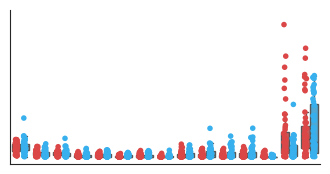

In [45]:
boxplot_accum_dpixel(df_comp)

In [47]:
selected_tp = df_stimulus.loc[df_stimulus['solenoid']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: x//10000)

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'solenoid_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
0,treatment,1,1.113402,0.291344,0.582687
1,treatment,1,2.828104,0.092628,0.463138
2,treatment,1,0.121149,0.727792,0.727792
3,treatment,1,2.551778,0.110170,0.463138
4,treatment,1,1.798164,0.179935,0.539804


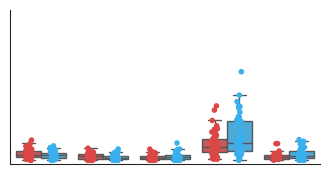

In [49]:
boxplot_accum_dpixel(df_comp)

In [51]:
selected_tp = df_stimulus.loc[df_stimulus['MP3']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: x//10000)

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'MP3_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
4,treatment,1,3.212639,0.073072,0.073072


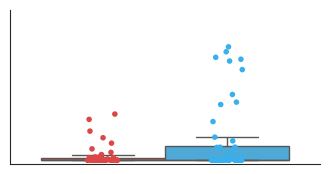

In [53]:
boxplot_accum_dpixel(df_comp)

In [55]:
selected_tp = df_stimulus.loc[df_stimulus['fs_15_20s']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: x//5000)

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'fs_15_20s_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
21,treatment,1,2.033832,0.153832,0.153832


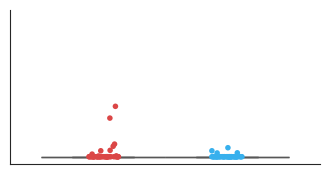

In [57]:
boxplot_accum_dpixel(df_comp)

In [59]:
selected_tp = df_stimulus.loc[df_stimulus['white LED']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: x//5000)

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'white LED_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
16,treatment,1,0.879731,0.348275,0.348275


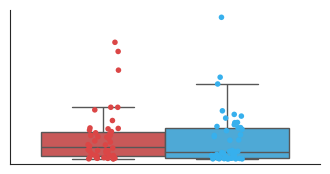

In [61]:
boxplot_accum_dpixel(df_comp)

In [63]:
selected_tp = df_stimulus.loc[df_stimulus['UV LED']>0].index
#selected_tp = selected_tp[selected_tp>12*6000]
starts = []
starts.append(selected_tp[0])
ends = []
for i in range(len(selected_tp)):
    if selected_tp[i]-selected_tp[i-1]>1:
        ends.append(selected_tp[i-1])
        starts.append(selected_tp[i])
ends.append(selected_tp[-1])
tp_temp = pd.DataFrame({'starts':starts,'ends':ends})
tp_temp['event_no'] = tp_temp['ends'].apply(lambda x: x//5000)

df_res = []
df_comp = []
for i in tp_temp.event_no.unique():
    ss_start = tp_temp.loc[tp_temp['event_no']==i].starts.min()
    ss_end = tp_temp.loc[tp_temp['event_no']==i].ends.max()
    sda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[:48, :].sum(axis=1).to_list()
    vda_temp = df_std_sv.loc[:, ss_start:ss_end].iloc[48:, :].sum(axis=1).to_list()
    df_comp_temp = pd.DataFrame({'SDA':sda_temp, 'VDA':vda_temp}).melt()
    df_comp_temp.columns = ['treatment', 'mi']
    df_output.append(df_comp_temp.rename(columns = {'mi':'UV LED_'+str(list(tp_temp.event_no.unique()).index(i)+1)}))
    df_comp_temp['param'] = 'event_'+str(i)
    res_temp = pg.kruskal(df_comp_temp, dv = 'mi', between = 'treatment')
    df_comp.append(df_comp_temp)
    df_res.append(res_temp)
df_res = pd.concat(df_res)
df_res.index = tp_temp.event_no.unique()
df_comp = pd.concat(df_comp)
df_res['padj'] = pg.multicomp(df_res['p-unc'])[1]
df_res

,Source,ddof1,H,p-unc,padj
21,treatment,1,2.575226,0.108549,0.108549


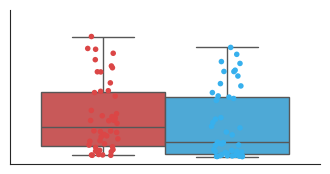

In [65]:
boxplot_accum_dpixel(df_comp)

In [192]:
df_temp = pd.concat(df_output,axis=1)
df_temp = df_temp.loc[:, ~df_temp.columns.duplicated(keep='first')]
df_temp.columns = df_temp.columns.str.replace('soft solenoid_', 'weak tap_')
df_temp.columns = df_temp.columns.str.replace('solenoid_', 'strong tap_')

output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S9 Behavior data of multi-stimulus assay.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_temp.to_excel(writer, sheet_name="Cumulative_MI", index=False)
    
df_temp

,treatment,weak tap_1,weak tap_2,green LED_1,green LED_2,red LED_1,red LED_2,red LED_3,red LED_4,red LED_5,...,purple LED_15,strong tap_1,strong tap_2,strong tap_3,strong tap_4,strong tap_5,MP3_1,fs_15_20s_1,white LED_1,UV LED_1
0,SDA,40.0,19414.0,2142.0,91.0,4052.0,481.0,13198.0,271.0,158.0,...,6226.0,10806.0,4634.0,8784.0,53544.0,5553.0,6062.0,0.0,6142.0,58375.0
1,SDA,3616.0,18299.0,31510.0,13461.0,3370.0,161.0,7366.0,10.0,41.0,...,172.0,7383.0,3839.0,9670.0,17515.0,9085.0,2122.0,0.0,23736.0,25533.0
2,SDA,533.0,1735.0,16.0,15.0,3636.0,23.0,7361.0,3.0,8.0,...,14011.0,5718.0,7360.0,11048.0,46359.0,7399.0,235.0,0.0,5586.0,17710.0
3,SDA,5213.0,17521.0,26771.0,130.0,11357.0,926.0,14599.0,6.0,0.0,...,20000.0,19624.0,11983.0,5316.0,6560.0,1364.0,12424.0,44.0,21875.0,28196.0
4,SDA,1770.0,20330.0,3338.0,56.0,1517.0,225.0,16900.0,16.0,58.0,...,6921.0,3862.0,4112.0,809.0,4125.0,3553.0,11.0,0.0,608.0,17301.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,VDA,7609.0,4847.0,86.0,2156.0,4702.0,42.0,122.0,1.0,2.0,...,6213.0,12125.0,7658.0,163.0,25211.0,9897.0,84.0,0.0,655.0,2304.0
92,VDA,38.0,48.0,279.0,379.0,975.0,3.0,1582.0,0.0,1.0,...,1316.0,1746.0,96.0,431.0,2579.0,695.0,41.0,26.0,58.0,317.0
93,VDA,124.0,189.0,8014.0,17197.0,726.0,16.0,7543.0,0.0,0.0,...,418.0,1801.0,1343.0,15142.0,7946.0,2465.0,15632.0,0.0,378.0,1013.0
94,VDA,3124.0,2911.0,12329.0,7898.0,716.0,6.0,7949.0,1.0,1.0,...,7669.0,845.0,2063.0,3530.0,11122.0,3361.0,16.0,0.0,585.0,20904.0
